In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score  # noqa: F401
from sklearn.model_selection import GridSearchCV, StratifiedKFold

_bootstrap_dependencies = (
    np,
    pd,
    RandomForestClassifier,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    GridSearchCV,
    StratifiedKFold,
)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')

def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()

repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Repository root: {repo_root}')
print('Imports listos para el entrenamiento de la red neuronal.')

Bootstrap imports loaded: 12
Repository root: /content/NATICUSdroid
Imports listos para el entrenamiento de la red neuronal.


In [2]:
from src.prepare_data import prepare_dataset

results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']

print('Resumen del dataset')
print(summary)
print('')
print('Artefactos generados')
for name, value in artifacts.items():
    print(f'{name}: {value}')

print('')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

Resumen del dataset
{'rows': 29332, 'columns': 87, 'feature_columns': 86, 'missing_values': 0, 'class_distribution': {'0': 14632, '1': 14700}, 'class_distribution_percent': {'0': 49.8841, '1': 50.1159}}

Artefactos generados
train_features: /content/NATICUSdroid/data/processed/X_train.csv
test_features: /content/NATICUSdroid/data/processed/X_test.csv
train_target: /content/NATICUSdroid/data/processed/y_train.csv
test_target: /content/NATICUSdroid/data/processed/y_test.csv
train_full: /content/NATICUSdroid/data/processed/train.csv
test_full: /content/NATICUSdroid/data/processed/test.csv
metadata: /content/NATICUSdroid/data/processed/split_metadata.json

X_train shape: (20532, 86)
X_test shape: (8800, 86)
y_train shape: (20532,)
y_test shape: (8800,)


Entrenando en: cpu
Epoch 10/50 | Loss: 0.0840
Epoch 20/50 | Loss: 0.0776
Epoch 30/50 | Loss: 0.0687
Epoch 40/50 | Loss: 0.0696
Epoch 50/50 | Loss: 0.0655

--- REPORTE FINAL ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4390
           1       0.97      0.97      0.97      4410

    accuracy                           0.97      8800
   macro avg       0.97      0.97      0.97      8800
weighted avg       0.97      0.97      0.97      8800



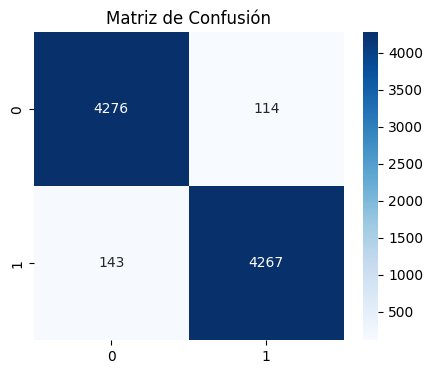

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# 2. Convertir los datos a Tensores de PyTorch
# Aseguramos que tengan el formato correcto que espera PyTorch
X_tr_t = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.long)
X_te_t = torch.tensor(X_test.values if hasattr(X_test, 'values') else X_test, dtype=torch.float32)
y_te_t = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test, dtype=torch.long)

# Crear DataLoaders
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=64, shuffle=False)

# 3. Definición del Modelo MLP
class RedNeuronal(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.estructura = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.estructura(x)

model = RedNeuronal(input_size=X_tr_t.shape[1]).to(device)

# 4. Entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

def train_network(epochs=50):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(train_loader):.4f}")

train_network()

# 5. Evaluación Final
model.eval()
with torch.no_grad():
    preds = model(X_te_t.to(device)).argmax(1).cpu().numpy()

print("\n--- REPORTE FINAL ---")
print(classification_report(y_test, preds))

# Matriz de Confusión
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()